<a href="https://colab.research.google.com/github/pavithra08188/PRODIGY_ML_01/blob/main/Smart_Student_Performance_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


path = "/content/student_performance_prediction (1).csv"

df = pd.read_csv(path)

df.head()

,Student ID,Study Hours per Week,Attendance Rate,Previous Grades,Participation in Extracurricular Activities,Parent Education Level,Passed
0,S00001,12.5,NaN,75.0,Yes,Master,Yes
1,S00002,9.3,95.3,60.6,No,High School,No
2,S00003,13.2,NaN,64.0,No,Associate,No
3,S00004,17.6,76.8,62.4,Yes,Bachelor,No
4,S00005,8.8,89.3,72.7,No,Master,No


In [ ]:
print(df.shape)
print(df.info())
print(df.describe())

(40000, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 7 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Student ID                                   40000 non-null  object 
 1   Study Hours per Week                         38005 non-null  float64
 2   Attendance Rate                              38008 non-null  float64
 3   Previous Grades                              38006 non-null  float64
 4   Participation in Extracurricular Activities  38000 non-null  object 
 5   Parent Education Level                       38000 non-null  object 
 6   Passed                                       38000 non-null  object 
dtypes: float64(3), object(4)
memory usage: 2.1+ MB
None
       Study Hours per Week  Attendance Rate  Previous Grades
count          38005.000000     38008.000000     38006.000000
mean               9.962744       

In [ ]:
print(df.isnull().sum())
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col].fillna(df[col].mean(), inplace=True)

Student ID                                        0
Study Hours per Week                           1995
Attendance Rate                                1992
Previous Grades                                1994
Participation in Extracurricular Activities    2000
Parent Education Level                         2000
Passed                                         2000
dtype: int64


/tmp/ipykernel_5914/4192173026.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


In [ ]:
df.drop_duplicates (inplace=True)
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Define categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
# Exclude 'Student ID' if it's not meant to be encoded
if 'Student ID' in cat_cols:
    cat_cols.remove('Student ID')

for col in cat_cols:
  df[col] = le.fit_transform(df[col])

df.to_csv("cleaned_student_data.csv", index=False)

df.head()

,Student ID,Study Hours per Week,Attendance Rate,Previous Grades,Participation in Extracurricular Activities,Parent Education Level,Passed
0,S00001,12.5,75.276323,75.0,1,4,1
1,S00002,9.3,95.300000,60.6,0,3,0
2,S00003,13.2,75.276323,64.0,0,0,0
3,S00004,17.6,76.800000,62.4,1,1,0
4,S00005,8.8,89.300000,72.7,0,4,0


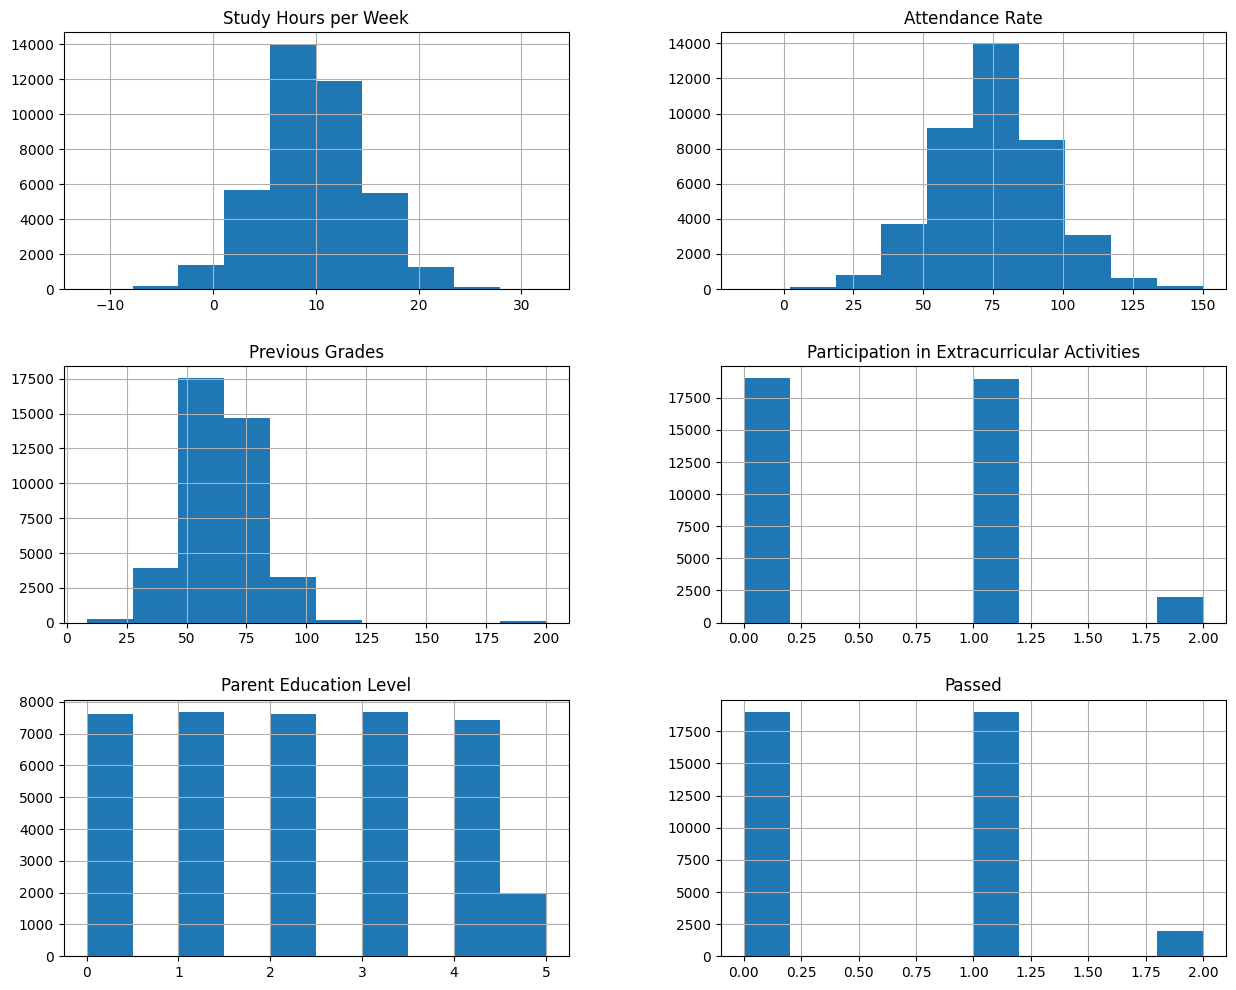

In [ ]:
df.hist(figsize=(15,12))
plt.show()

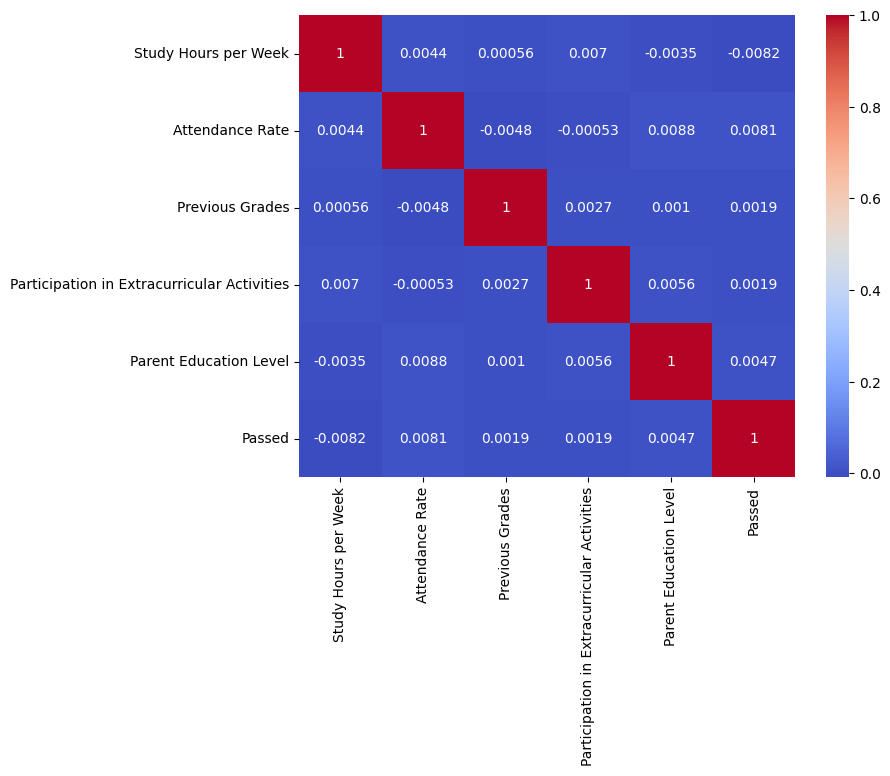

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.show()

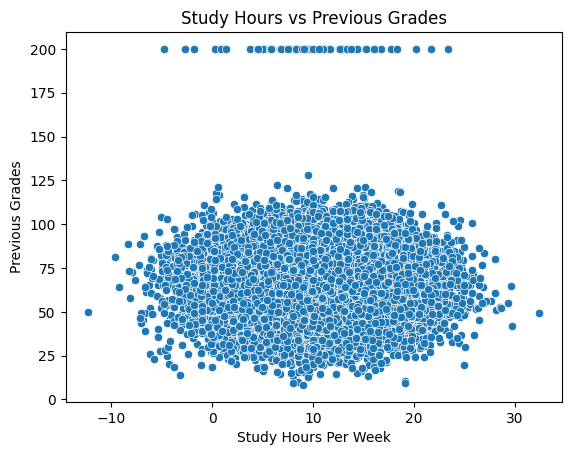

In [ ]:
sns.scatterplot(
    x=df['Study Hours per Week'],
    y=df['Previous Grades']
)

plt.xlabel("Study Hours Per Week")

plt.ylabel("Previous Grades")

plt.title("Study Hours vs Previous Grades")

plt.show()

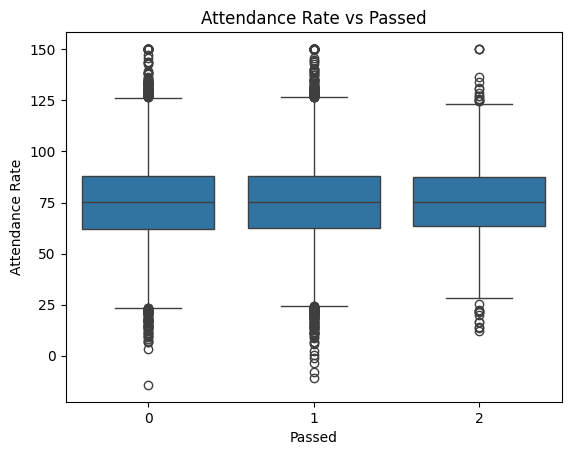

In [ ]:
sns.boxplot(
    x=df['Passed'],
    y=df['Attendance Rate']
)

plt.xlabel("Passed")

plt.ylabel("Attendance Rate")

plt.title("Attendance Rate vs Passed")

plt.show()

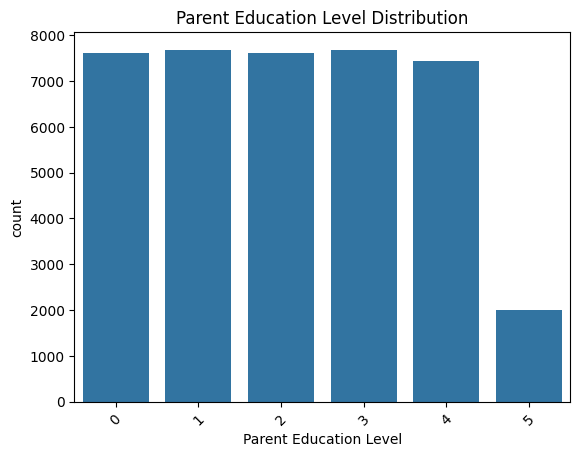

In [ ]:
sns.countplot(
    x=df['Parent Education Level']
)

plt.xticks(rotation=45)

plt.title("Parent Education Level Distribution")

plt.show()

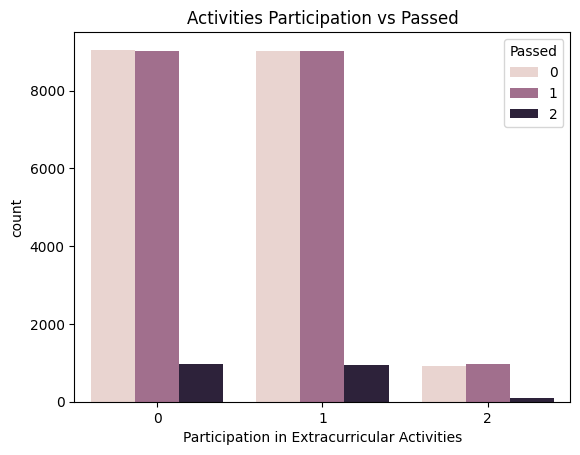

In [ ]:
sns.countplot(
    x='Participation in Extracurricular Activities',
    hue='Passed',
    data=df
)

plt.title("Activities Participation vs Passed")
plt.show()

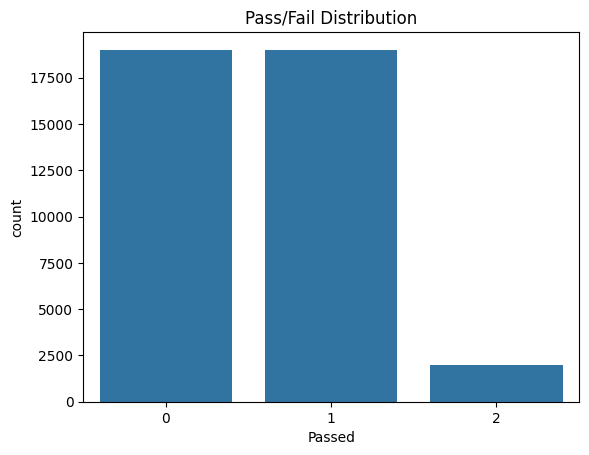

In [ ]:
sns.countplot(
    x=df['Passed']
)

plt.title("Pass/Fail Distribution")

plt.show()

In [ ]:
print(df['Parent Education Level'].value_counts())

Parent Education Level
1    7685
3    7675
2    7610
0    7604
4    7426
5    2000
Name: count, dtype: int64


In [ ]:
df['Study Attendance Score'] = (
    df['Study Hours per Week'] *
    df['Attendance Rate']
)

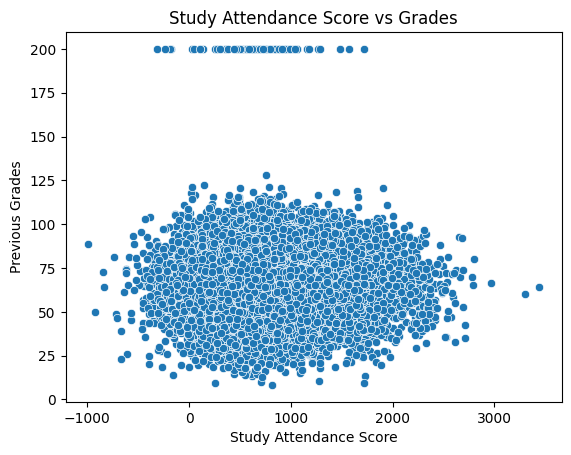

In [ ]:
sns.scatterplot(
    x=df['Study Attendance Score'],
    y=df['Previous Grades']
)

plt.title("Study Attendance Score vs Grades")

plt.show()

In [ ]:

import numpy as np

df['Future Grade'] = (
    df['Previous Grades']
    + (df['Study Hours per Week'] * 0.8)
    + (df['Attendance Rate'] * 0.2)
    + np.random.normal(0, 5, len(df))
)

In [ ]:
X = df.drop(
    ['Student ID', 'Future Grade'],
    axis=1
    )

y = df['Future Grade']